In [2]:
install.packages(c("psych", "psychTools", "GPArotation"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [12]:
library(psych)
library(psychTools)   #Contiene el dataset bfi
library(GPArotation)  #Motor de rotación usado por fa() para promax/oblimin

In [11]:
#25 items de personalidad (5 factores)
datos <- psychTools::bfi[, 1:25]
datos <- na.omit(datos)

head(datos)

,A1,A2,A3,A4,A5,C1,C2,C3,C4,C5,⋯,N1,N2,N3,N4,N5,O1,O2,O3,O4,O5
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
61617,2,4,3,4,4,2,3,3,4,4,⋯,3,4,2,2,3,3,6,3,4,3
61618,2,4,5,2,5,5,4,4,3,4,⋯,3,3,3,5,5,4,2,4,3,3
61620,5,4,5,4,4,4,5,4,2,5,⋯,4,5,4,2,3,4,2,5,5,2
61621,4,4,6,5,5,4,4,3,5,5,⋯,2,5,2,4,1,3,3,4,3,5
61622,2,3,3,4,5,4,4,5,3,2,⋯,2,3,4,4,3,3,3,4,3,3
61623,6,6,5,6,5,6,6,6,1,3,⋯,3,5,2,2,3,4,3,5,6,1


# Rotaciones Ortogonales (Varimax y Quartimax)

In [6]:
fa_varimax   <- fa(datos, nfactors = 5, fm = "ml", rotate = "varimax")
fa_quartimax <- fa(datos, nfactors = 5, fm = "ml", rotate = "quartimax")

cat("----- VARIMAX: Matriz de Configuración -----\n")
print(fa_varimax$loadings, cutoff = 0.30, digits = 2)

#Propiedad teórica: en ortogonal, Configuración debe ser igual a Estructura
cat("\n¿Configuración == Estructura en Varimax?\n")
print(all.equal(unclass(fa_varimax$loadings), unclass(fa_varimax$Structure)))

#No debería existir correlación entre factores en una solución ortogonal
cat("\nPhi en Varimax (no aplica en rotación ortogonal):\n")
print(fa_varimax$Phi)

----- VARIMAX: Matriz de Configuración -----

Loadings:
   ML2   ML1   ML3   ML5   ML4  
A1                   -0.39      
A2                    0.60      
A3                    0.66      
A4                    0.45      
A5        0.35        0.58      
C1              0.53            
C2              0.62            
C3              0.55            
C4             -0.65            
C5             -0.57            
E1       -0.59                  
E2       -0.67                  
E3        0.49        0.31  0.31
E4        0.61        0.36      
E5        0.49  0.31            
N1  0.82                        
N2  0.79                        
N3  0.71                        
N4  0.56 -0.37                  
N5  0.52                        
O1                          0.52
O2                         -0.45
O3                          0.61
O4                          0.37
O5                         -0.51

                ML2  ML1  ML3  ML5  ML4
SS loadings    2.69 2.32 2.03 1.98 1.56
Propo

# Rotaciones Oblicuas (Promax y Oblimin)

In [5]:
fa_promax  <- fa(datos, nfactors = 5, fm = "ml", rotate = "promax")
fa_oblimin <- fa(datos, nfactors = 5, fm = "ml", rotate = "oblimin")  # delta = 0 por defecto

cat("----- OBLIMIN (delta = 0): Matriz de CONFIGURACIÓN -----\n")
print(fa_oblimin$loadings, cutoff = 0.30, digits = 2)

cat("\n----- OBLIMIN: Matriz de ESTRUCTURA (correlaciones ítem-factor) -----\n")
print(fa_oblimin$Structure, digits = 2)

cat("\n----- OBLIMIN: Matriz Phi (correlación ENTRE factores) -----\n")
print(fa_oblimin$Phi, digits = 2)

----- OBLIMIN (delta = 0): Matriz de CONFIGURACIÓN -----

Loadings:
   ML2   ML3   ML5   ML4   ML1  
A1       -0.39                  
A2        0.63                  
A3        0.69                  
A4        0.47                  
A5        0.58                  
C1              0.54            
C2              0.64            
C3              0.57            
C4             -0.67            
C5             -0.58            
E1                    0.56      
E2                    0.65      
E3                   -0.34  0.33
E4        0.36       -0.54      
E5                   -0.39      
N1  0.87                        
N2  0.82                        
N3  0.66                        
N4  0.41              0.44      
N5  0.44                        
O1                          0.54
O2                         -0.46
O3                          0.64
O4                    0.36  0.37
O5                         -0.52

                ML2  ML3  ML5  ML4  ML1
SS loadings    2.43 1.99 1.99 1.8

In [18]:
#¿Ortogonal u Oblicua?
corr_maxima <- max(abs(fa_oblimin$Phi[upper.tri(fa_oblimin$Phi)]))
cat("Correlación interfactorial máxima (Oblimin, delta=0):", round(corr_maxima, 3), "\n\n")

if (corr_maxima < 0.32) {
  cat("-> Correlaciones bajas (r < 0.32): Es justificable optar por rotación ortogonal.\n")
} else {
  cat("-> Correlaciones relevantes (r >= 0.32): Se debe mantener la solución oblicua.\n")
}

Correlación interfactorial máxima (Oblimin, delta=0): 0.319 

-> Correlaciones bajas (r < 0.32): Es justificable optar por rotación ortogonal.


# Visualizaciones

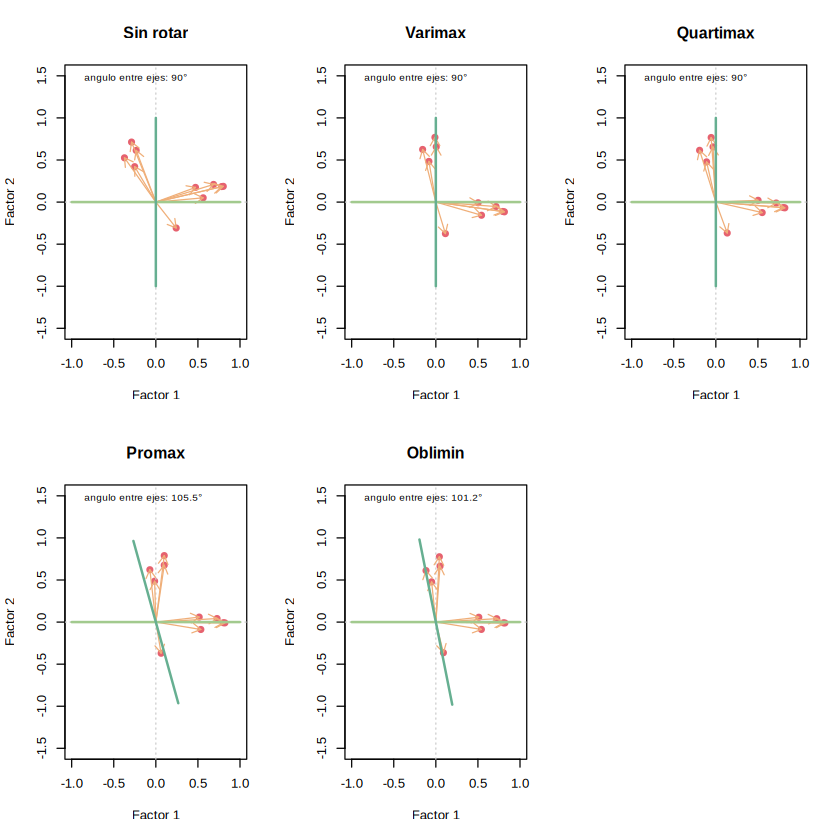

In [24]:
library(psych)
library(psychTools)
library(GPArotation)

#Visualizamos 2 factores
#5 items de Amabilidad + 5 de Neuroticismo
items_2f <- psychTools::bfi[, c(1:5, 16:20)]
items_2f <- na.omit(items_2f)

#Extraccion sin rotar + las 4 rotaciones
fa_sin_rotar <- fa(items_2f, nfactors = 2, fm = "ml", rotate = "none")
fa_varimax   <- fa(items_2f, nfactors = 2, fm = "ml", rotate = "varimax")
fa_quartimax <- fa(items_2f, nfactors = 2, fm = "ml", rotate = "quartimax")
fa_promax    <- fa(items_2f, nfactors = 2, fm = "ml", rotate = "promax")
fa_oblimin   <- fa(items_2f, nfactors = 2, fm = "ml", rotate = "oblimin")

#Funcion para graficar una solucion: items + ejes de factores
graficar_rotacion <- function(fa_obj, titulo) {
  L <- unclass(fa_obj$loadings)[, 1:2]
  Phi <- fa_obj$Phi   #NULL si es ortogonal

  plot(L, xlim = c(-1, 1), ylim = c(-1, 1), pch = 19, col = "#e6626f",
       xlab = "Factor 1", ylab = "Factor 2", main = titulo, asp = 1)
  abline(h = 0, v = 0, col = "gray80", lty = 3)
  arrows(0, 0, L[, 1], L[, 2], length = 0.08, col = "#efae78")

  # El angulo entre ejes ES arccos(Phi) -> mismo r = cos(theta)
  angulo <- if (is.null(Phi)) pi / 2 else acos(Phi[1, 2])

  segments(-1, 0, 1, 0, col = "#a2ca8e", lwd = 2)               #eje Factor 1
  segments(-cos(angulo), -sin(angulo), cos(angulo), sin(angulo),  #eje Factor 2
           col = "#66af91", lwd = 2)

  legend("topleft", bty = "n", cex = 0.75,
         legend = paste0("angulo entre ejes: ", round(angulo * 180 / pi, 1), "°"))
}

par(mfrow = c(2, 3))
graficar_rotacion(fa_sin_rotar, "Sin rotar")
graficar_rotacion(fa_varimax,   "Varimax")
graficar_rotacion(fa_quartimax, "Quartimax")
graficar_rotacion(fa_promax,    "Promax")
graficar_rotacion(fa_oblimin,   "Oblimin")
par(mfrow = c(1, 1))

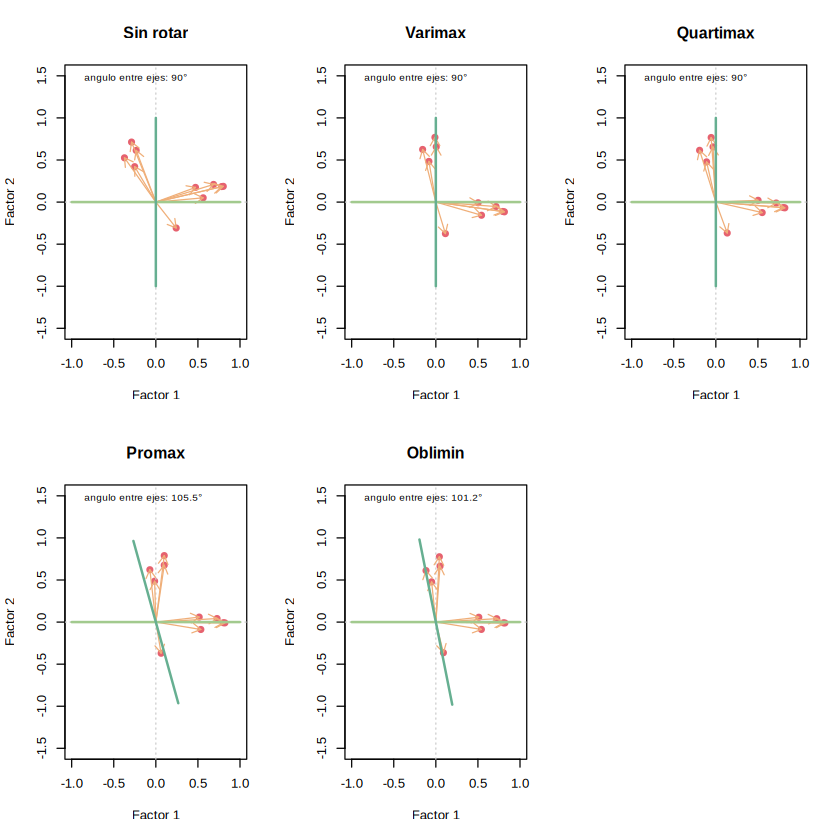